In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [40]:
from sklearn.datasets import load_wine

In [41]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

print("Feature Names:")
print(wine.feature_names)

print("\nTarget Names:")
print(wine.target_names)

print("\nNumber of Samples:")
print(wine.data.shape[0])

print("\nFirst Five Records:")
df.head()


Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Names:
['class_0' 'class_1' 'class_2']

Number of Samples:
178

First Five Records:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [42]:
df['target'] = wine.target

In [43]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [44]:
X = df.drop('target', axis=1)
y = df['target']

In [45]:
print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (178, 13)
y shape:  (178,)


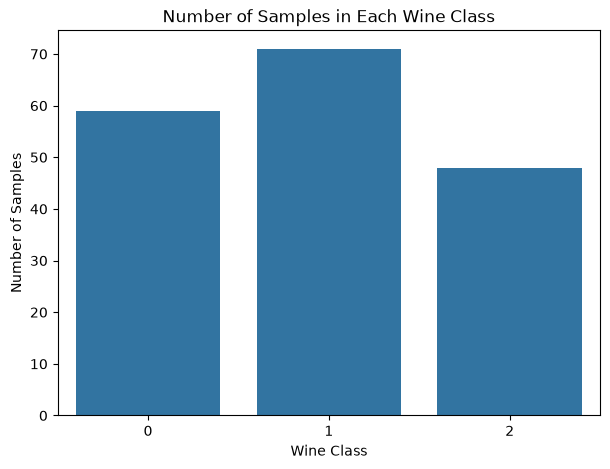

In [46]:
plt.figure(figsize=(7,5))
sns.countplot(x=y)
plt.title("Number of Samples in Each Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.show()

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [48]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (142, 13)
Testing Features Shape: (36, 13)
Training Target Shape: (142,)
Testing Target Shape: (36,)


In [49]:
n_est = 100
r_state = 0
model = RandomForestClassifier(n_estimators=n_est, random_state=r_state)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 0 1 2 2 0 1 0 2 2 0 2 1 0 2 2 1 0 1 2 2 1 2 0 1 0 1 1 0 0 1 1 0 1]


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [50]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


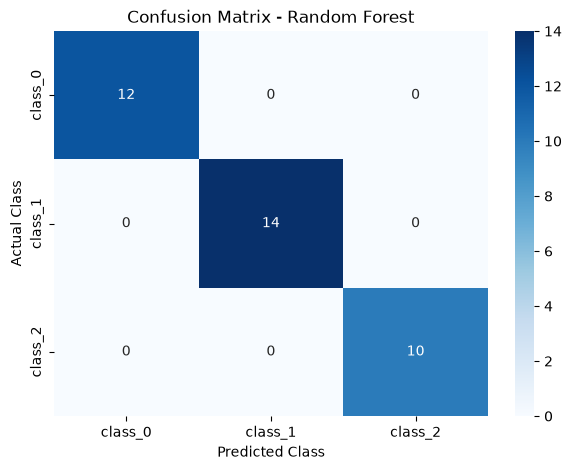

In [51]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [52]:
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
print("Feature Importance:")
display(importance_df)

Feature Importance:


,Feature,Importance
12,proline,0.190562
9,color_intensity,0.176065
6,flavanoids,0.170417
0,alcohol,0.129309
11,od280/od315_of_diluted_wines,0.099877
10,hue,0.068693
5,total_phenols,0.048265
1,malic_acid,0.028588
4,magnesium,0.026705
3,alcalinity_of_ash,0.021079


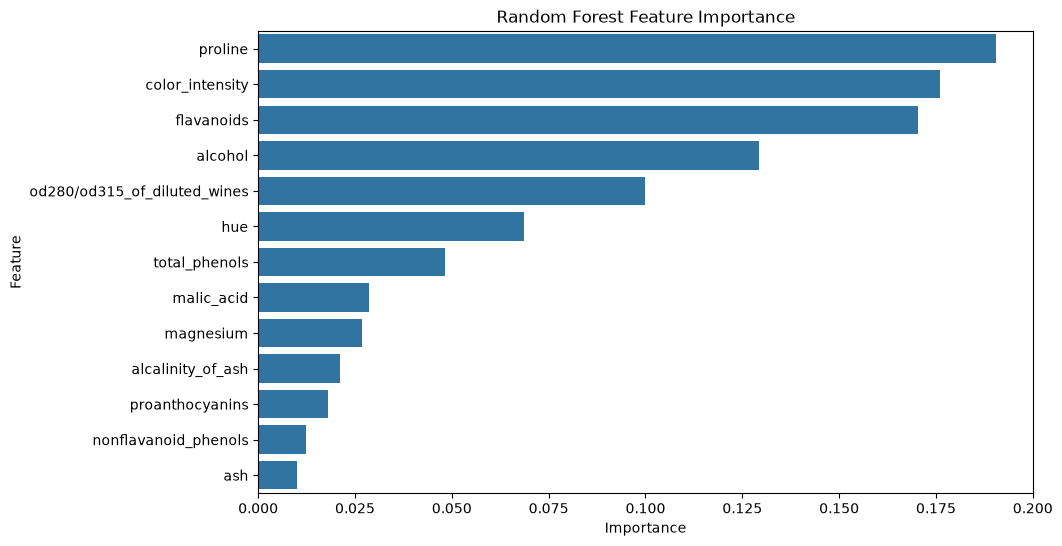

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [54]:
most_important_feature = importance_df.iloc[0]

print("Most Important Feature:",
      most_important_feature['Feature'])

print("Importance:",
      most_important_feature['Importance'])

Most Important Feature: proline
Importance: 0.19056162826535


In [55]:
new_samples = pd.DataFrame(
    wine.data[:3],
    columns=wine.feature_names
)

print("Three New Wine Samples:")
display(new_samples)

Three New Wine Samples:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


In [56]:
new_predictions = model.predict(new_samples)

print("Predictions for New Wine Samples:")

for i, prediction in enumerate(new_predictions, start=1):
    print(f"New Wine Sample {i}: Wine Class {prediction}")

Predictions for New Wine Samples:
New Wine Sample 1: Wine Class 0
New Wine Sample 2: Wine Class 0
New Wine Sample 3: Wine Class 0
